# 🧠 PubMed 200k RCT Kaggle Notebook
Complete pipeline for biomedical text classification

In [2]:
# Install dependencies
!pip install kagglehub pandas scikit-learn scipy joblib

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import re
import os

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from scipy.sparse import hstack

In [4]:
# Download dataset
path = kagglehub.dataset_download("matthewjansen/pubmed-200k-rtc")
print("Dataset path:", path)

Dataset path: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc


In [5]:
import os

base_path = "/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc"

for root, dirs, files in os.walk(base_path):
    print("DIR:", root)
    for file in files:
        print("  FILE:", file)

DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc
DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign
  FILE: dev.csv
  FILE: test.txt
  FILE: dev.txt
  FILE: train.csv
  FILE: test.csv
DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT_numbers_replaced_with_at_sign/train
  FILE: train.txt
DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT
  FILE: dev.csv
  FILE: test.txt
  FILE: dev.txt
  FILE: train.csv
  FILE: test.csv
DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_200k_RCT/train
  FILE: train.txt
DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT
  FILE: dev.csv
  FILE: test.txt
  FILE: train.txt
  FILE: dev.txt
  FILE: train.csv
  FILE: test.csv
DIR: /kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT_numbers_replaced_with_at_sign
  FILE: dev.csv
  FILE: test.txt
  FILE: train.txt
  FILE: dev.txt
  FILE: train.csv
  FILE:

In [6]:
# Load dataset
def load_pubmed_file(file_path):
    texts, labels = [], []
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line == "" or line.startswith("###"):
                continue
            if "\t" in line:
                label, text = line.split("\t")
                texts.append(text)
                labels.append(label)
    return pd.DataFrame({"text": texts, "label": labels})

base_path = "/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT"

train_path = os.path.join(base_path, "train.txt")
test_path  = os.path.join(base_path, "test.txt")

train_df = load_pubmed_file(train_path)
test_df  = load_pubmed_file(test_path)

print(len(train_df), len(test_df))
train_df.head()

180040 30135


,text,label
0,To investigate the efficacy of 6 weeks of dail...,OBJECTIVE
1,A total of 125 patients with primary knee OA w...,METHODS
2,Outcome measures included pain reduction and i...,METHODS
3,Pain was assessed using the visual analog pain...,METHODS
4,Secondary outcome measures included the Wester...,METHODS


In [7]:
import os
import pandas as pd

def load_pubmed_file(file_path):
    texts, labels = [], []

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()

            if line == "" or line.startswith("###"):
                continue

            if "\t" in line:
                label, text = line.split("\t")
                texts.append(text)
                labels.append(label)

    return pd.DataFrame({"text": texts, "label": labels})


# ✅ CORRECT PATH
base_path = "/kaggle/input/datasets/matthewjansen/pubmed-200k-rtc/PubMed_20k_RCT"

train_path = os.path.join(base_path, "train.txt")
test_path  = os.path.join(base_path, "test.txt")

# Load data
train_df = load_pubmed_file(train_path)
test_df  = load_pubmed_file(test_path)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
train_df.head()

Train size: 180040
Test size: 30135


,text,label
0,To investigate the efficacy of 6 weeks of dail...,OBJECTIVE
1,A total of 125 patients with primary knee OA w...,METHODS
2,Outcome measures included pain reduction and i...,METHODS
3,Pain was assessed using the visual analog pain...,METHODS
4,Secondary outcome measures included the Wester...,METHODS


In [8]:
# Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

In [9]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

In [10]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, train_df['label'])

MultinomialNB()

In [11]:
# Character N-grams
char_vec = CountVectorizer(analyzer='char', ngram_range=(3,5))
X_train_char = char_vec.fit_transform(train_df['clean_text'])
X_test_char  = char_vec.transform(test_df['clean_text'])

In [12]:
# Combine features
X_train_final = hstack([X_train_tfidf, X_train_char])
X_test_final  = hstack([X_test_tfidf, X_test_char])

In [13]:
# Final Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, train_df['label'])

LogisticRegression(max_iter=1000)

In [14]:
# Evaluation
y_pred = model.predict(X_test_final)

print("Accuracy:", accuracy_score(test_df['label'], y_pred))
print("Macro F1:", f1_score(test_df['label'], y_pred, average='macro'))
print(classification_report(test_df['label'], y_pred))

Accuracy: 0.7883524141363862
Macro F1: 0.7207012062244762
              precision    recall  f1-score   support

  BACKGROUND       0.60      0.61      0.60      3621
 CONCLUSIONS       0.71      0.69      0.70      4571
     METHODS       0.86      0.89      0.88      9897
   OBJECTIVE       0.59      0.54      0.56      2333
     RESULTS       0.86      0.86      0.86      9713

    accuracy                           0.79     30135
   macro avg       0.72      0.72      0.72     30135
weighted avg       0.79      0.79      0.79     30135



In [15]:
# Save model
import joblib
joblib.dump(model, "pubmed_model.pkl")

['pubmed_model.pkl']

In [17]:
# Baseline 1: TF-IDF + Logistic Regression
from sklearn.linear_model import LogisticRegression

baseline_tfidf = LogisticRegression(max_iter=1000)
baseline_tfidf.fit(X_train_tfidf, train_df['label'])

pred_tfidf = baseline_tfidf.predict(X_test_tfidf)

In [18]:
# Baseline 2: Character N-grams only
char_model = LogisticRegression(max_iter=1000)
char_model.fit(X_train_char, train_df['label'])

pred_char = char_model.predict(X_test_char)

In [19]:
fusion_model = LogisticRegression(max_iter=1000)
fusion_model.fit(X_train_final, train_df['label'])

pred_fusion = fusion_model.predict(X_test_final)

In [20]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')

    print(f"{name}")
    print("Accuracy:", acc)
    print("Macro-F1:", f1)
    print("-"*40)

    return acc, f1

In [21]:
results = []

results.append(("TF-IDF", *evaluate_model("TF-IDF", test_df['label'], pred_tfidf)))
results.append(("Char N-gram", *evaluate_model("Char N-gram", test_df['label'], pred_char)))
results.append(("Fusion (Proposed)", *evaluate_model("Fusion", test_df['label'], pred_fusion)))

TF-IDF
Accuracy: 0.8003982080637133
Macro-F1: 0.7368187775620543
----------------------------------------
Char N-gram
Accuracy: 0.7877219180355068
Macro-F1: 0.7199912800704145
----------------------------------------
Fusion
Accuracy: 0.7883524141363862
Macro-F1: 0.7207012062244762
----------------------------------------


In [22]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Macro-F1"])
print(results_df)

               Model  Accuracy  Macro-F1
0             TF-IDF  0.800398  0.736819
1        Char N-gram  0.787722  0.719991
2  Fusion (Proposed)  0.788352  0.720701


In [23]:
probs = fusion_model.predict_proba(X_test_final)

# Example: show confidence for first sample
print("Probabilities:", probs[0])

Probabilities: [0.20454101 0.03263593 0.25665904 0.47788101 0.02828301]


In [24]:
results_df.to_csv("results_table.csv", index=False)

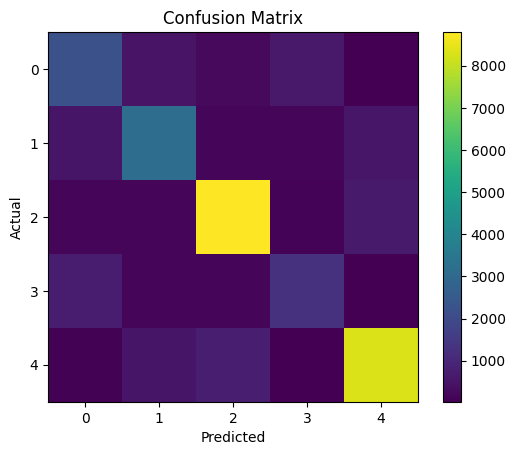

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(test_df['label'], pred_fusion)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(len(set(test_df['label']))))
plt.yticks(np.arange(len(set(test_df['label']))))

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(test_df['label'], pred_fusion))

              precision    recall  f1-score   support

  BACKGROUND       0.60      0.61      0.60      3621
 CONCLUSIONS       0.71      0.69      0.70      4571
     METHODS       0.86      0.89      0.88      9897
   OBJECTIVE       0.59      0.54      0.56      2333
     RESULTS       0.86      0.86      0.86      9713

    accuracy                           0.79     30135
   macro avg       0.72      0.72      0.72     30135
weighted avg       0.79      0.79      0.79     30135



In [27]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Macro-F1"])
print("\nFinal Results Table:")
print(results_df)


Final Results Table:
               Model  Accuracy  Macro-F1
0             TF-IDF  0.800398  0.736819
1        Char N-gram  0.787722  0.719991
2  Fusion (Proposed)  0.788352  0.720701


In [32]:
print(results_df)

               Model  Accuracy  Macro-F1
0             TF-IDF  0.800398  0.736819
1        Char N-gram  0.787722  0.719991
2  Fusion (Proposed)  0.788352  0.720701


In [36]:
results_df.to_csv("final_results.csv", index=False)